# PToTR Paper Case Study 02: Positron Emission Tomography (PET) Image Reconstruction

## Maximum Likelihood - Expectation Maximization (ML-EM)

NOTE: `ptotr-paper-02-pet-01-data.ipynb` must be run prior to running this notebook, as all data is processed in that notebook and then saved to files.


### Import dependencies

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt

# helper functions for this notebook
from ptotr_paper_functions import (
    fit_ml_em_sparse,
    ptotr_pet_compute_B_true,
    ptotr_pet_compute_Xs,
    ptotr_pet_compute_Ys,
)

### Load PToTR data

In [2]:
# true parameter tensor (numpy ndarray)
B_true = ptotr_pet_compute_B_true(savedata="Btrue")
B_true = B_true.reshape(4*240, 256*256)
print(f"B_true shape: {B_true.shape}")

Loading B_true: data/ptotr_pet_Btrue.npy
B_true shape: (960, 65536)


In [3]:
# responses (numpy ndarray)
Ys, Ys_ind = ptotr_pet_compute_Ys(B_true, savedata="Ys")
print(f"Ys shape: {Ys.shape}")

Loading Ys: data/ptotr_pet_Ys.npy
Loading Ys_ind: data/ptotr_pet_Ys_ind.npy
Ys shape: (4, 240, 41952)


In [4]:
# covariates (numpy ndarray)
Xs = ptotr_pet_compute_Xs(Ys_ind, savedata="Xs")#.double()
print(f"Xs shape: {Xs.shape}")

Loading Xs: data/ptotr_pet_Xs.tns
Xs shape: (256, 256, 41952)


In [5]:
%%time
rmse_df, saved_imgs, final_B_by_pp = fit_ml_em_sparse(
    Y=Ys,
    X_tensor=Xs,
    B0=B_true,
    pp_values=(1, 2, 4, 8, 16),
    p1=2622,
    itint=5,
    itmax=120,
    epsDivZero=1e-10,
    stoptol=-1,
    out_rmse_csv="data/ml_em_rmses.csv",
    out_slices_pkl="data/ml_em_slices.pkl",
)

ml_em_sparseX, 1% data; iteration: 0 5 10 15 20 25 30 35 40 45 50 55 60 65 70 75 80 85 90 95 100 105 110 115 120 
ml_em_sparseX, 2% data; iteration: 0 5 10 15 20 25 30 35 40 45 50 55 60 65 70 75 80 85 90 95 100 105 110 115 120 
ml_em_sparseX, 4% data; iteration: 0 5 10 15 20 25 30 35 40 45 50 55 60 65 70 75 80 85 90 95 100 105 110 115 120 
ml_em_sparseX, 8% data; iteration: 0 5 10 15 20 25 30 35 40 45 50 55 60 65 70 75 80 85 90 95 100 105 110 115 120 
ml_em_sparseX, 16% data; iteration: 0 5 10 15 20 25 30 35 40 45 50 55 60 65 70 75 80 85 90 95 100 105 110 115 120 
Saved RMSEs to data/ml_em_rmses.csv
Saved image slices to data/ml_em_slices.pkl
CPU times: user 27min, sys: 16.3 s, total: 27min 17s
Wall time: 27min 18s


### Plot RMSE values

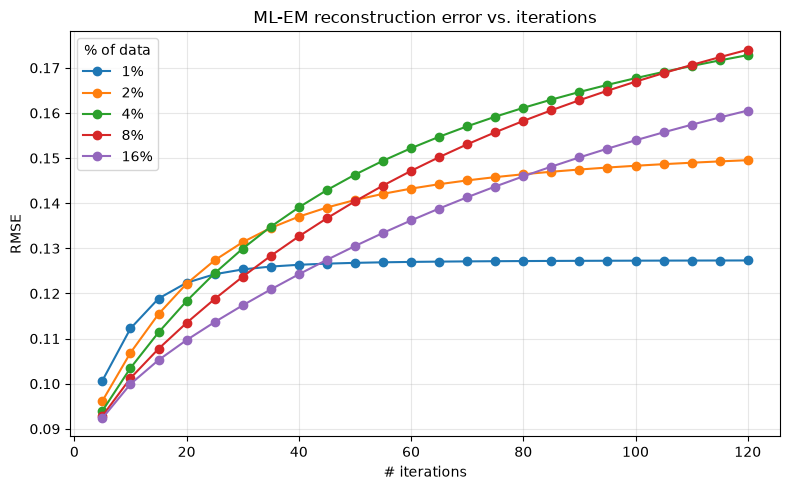

In [6]:
# Columns are iteration counts
x = [int(c) for c in rmse_df.columns]

# Plot one line per percentage of data
plt.figure(figsize=(8, 5))
for row_label in rmse_df.index:
    plt.plot(x, rmse_df.loc[row_label].values, marker='o', label=row_label)

plt.xlabel("# iterations")
plt.ylabel("RMSE")
plt.title("ML-EM reconstruction error vs. iterations")
plt.legend(title="% of data")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Plot reconstructed images

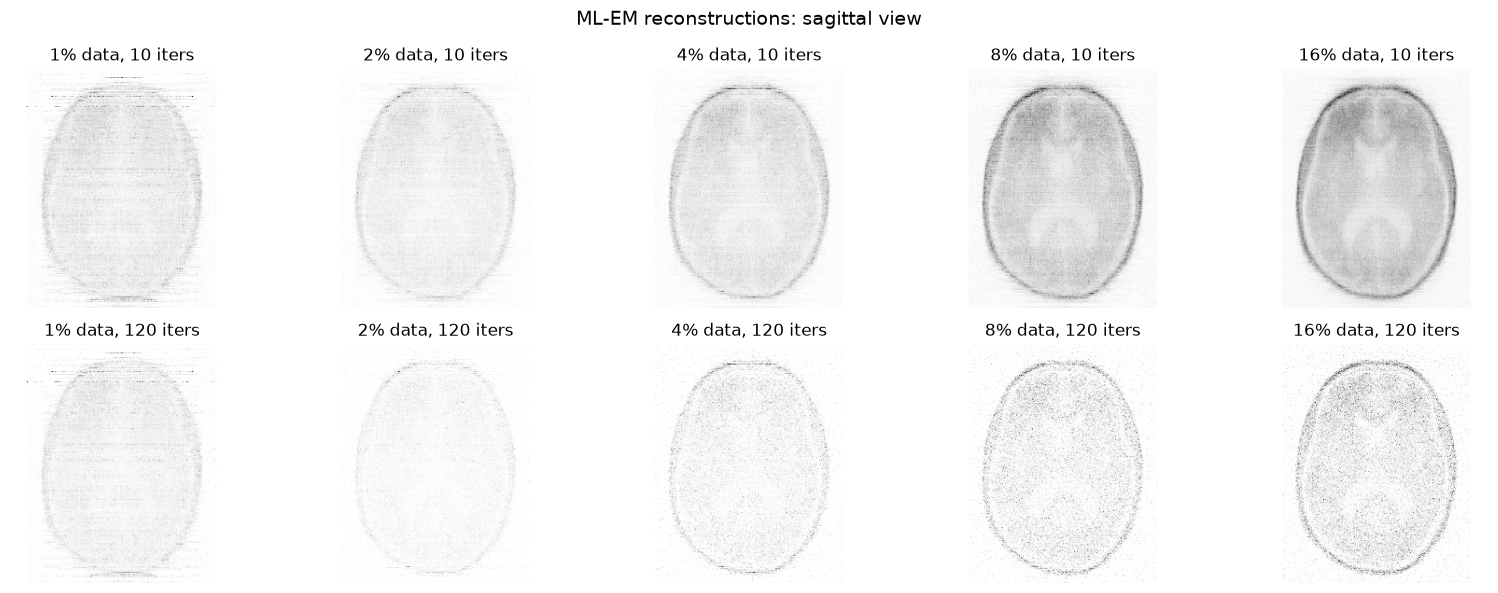

In [7]:
view = "sagittal"   # "axial", "coronal", "sagittal"

percents = [1, 2, 4, 8, 16]
iters = [10, 120]

fig, axs = plt.subplots(2, 5, figsize=(16, 6))

for i, it in enumerate(iters):
    for j, pp in enumerate(percents):
        axs[i, j].imshow(saved_imgs[(pp, it, view)][:,::-1].T, cmap="gray_r")
        axs[i, j].set_title(f"{pp}% data, {it} iters")
        axs[i, j].axis("off")

plt.suptitle(f"ML-EM reconstructions: {view} view", fontsize=14)
plt.tight_layout()
plt.show()